# **Post-Treatement of the simulaiton for the Tsanfleuron glacier**
The aim of this notebook is to import the different simulations of the Tsanfleuron glacier and calculate the volumes returns by the different methods.

## **Input :**
* MPS simulation set run with considering the ti as hard conditionning data
* MPS simulation set run without considering the ti as hard conditionning data
* GRF simulation
* Kriging estimation

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages
import georasters as gr


## Import the simulations

In [23]:
path_output_krig = '../simulation_output_krig/'
path_output_MPS  = '../simulation_output/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name      = os.listdir(path_output_MPS)

exec(open('../functions/03_indice_calculation_functions.py').read())

In [24]:
simulation_name, simulation_name_krig

(['tsanfleuron_data_simu.pickle'], [])

In [25]:
with open(path_output_MPS+simulation_name[0],'rb') as file:
        real_alt, simu_sets, mask, referential= pickle.load(file)
#with open(path_output_krig+simulation_name_krig[0],'rb') as file:
#        real_alt, krig, mask, referential= pickle.load(file)

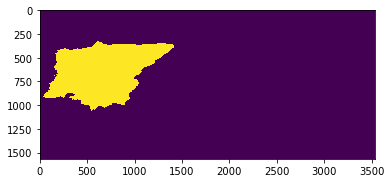

In [26]:
plt.imshow(mask)

## Import the DEM

In [6]:
file_path_DEM = '../data/DEM/pickle/DEM_glacier_cut.pickle'
file_path_DEM = '../data/DEM/pickle/DEM_glacier_cyprien.pickle'

if os.path.isfile(file_path_DEM):
    print('Le fichier est présent. import')
    with open(file_path_DEM,'rb')as file:
        data_DEM_Glacier = pickle.load(file)

else:
    print('error')

Le fichier est présent. import


In [27]:
file_path_DEM = '../data/DEM/tif/dem_2019.tif'

data_DEM_Glacier = gr.from_file(file_path_DEM)
data_DEM_Glacier = data_DEM_Glacier.raster.data
data_DEM_Glacier[mask!=1]= np.nan

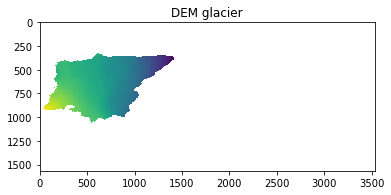

In [28]:
plt.imshow(data_DEM_Glacier)
plt.title('DEM glacier')
plt.show()

## We extract the glaier zone for the different simulation sets

In [29]:
def extract(simu, mask):
    simuOut = np.full((simu.shape[0],simu.shape[1]),np.nan)
    simu[mask!=1] = np.nan
    return simu

In [30]:
def recut(simu):
    simu_cut = np.full((1200,1500),np.nan)
    simu_cut = simu[:1200,:1500]
    return simu_cut                       

In [31]:
set_name  = ['MPS', 'MPS2', 'GRF']
simus_cut = {}

for i in range(len(simu_sets)-1):
    simus_cut[set_name[i]] = []
    for simu in simu_sets[i]:
        simus_cut[set_name[i]].append(recut(extract(simu, mask)))
        
#simus_cut['Krig']=[]
#simus_cut['Krig'].append(recut(extract(krig[0],mask)))

mask = recut(mask)
data_DEM_Glacier = recut(data_DEM_Glacier)

In [32]:
simus_cut.keys()

dict_keys(['MPS', 'MPS2'])

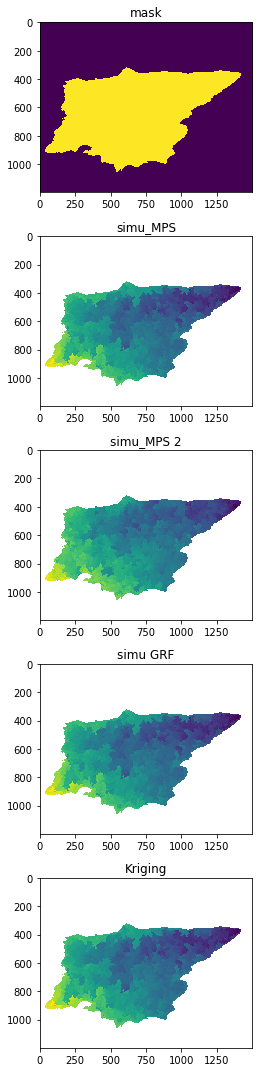

In [33]:
plt.subplots(5,1,figsize=(15,15))
plt.subplot(5,1,1)
plt.imshow(mask)
plt.title('mask')
plt.subplot(5,1,2)
plt.imshow(simus_cut['MPS'][0])
plt.title('simu_MPS')
plt.subplot(5,1,3)
plt.imshow(simus_cut['MPS2'][0])
plt.title('simu_MPS 2')
plt.subplot(5,1,4)
plt.imshow(simus_cut['MPS'][0])
plt.title('simu GRF')
plt.subplot(5,1,5)
plt.imshow(simus_cut['MPS'][0])
plt.title('Kriging')
plt.tight_layout()
plt.show()

## We calcule the different volumes

In [34]:
volumes   = {}
diff_mean = {}
for key in simus_cut.keys():
    volumes[key]=[]
    diff_list = []
    for simu in simus_cut[key]:
        diff = data_DEM_Glacier-simu
        diff_list.append(diff)
        diff[diff<0] = np.nan  #to remove the diff inf to zero
        volumes[key].append(np.nansum(diff)*4)
        
    diff_mean[key]=[np.mean(diff_list,axis=0)]

In [35]:
for key in volumes.keys():
    print('Mean volumen for the {} set is : {}m3 '.format(str(key),str(np.mean(volumes[key]))))

Mean volumen for the MPS set is : 113686813.41871612m3 
Mean volumen for the MPS2 set is : 129014091.73593715m3 


In [115]:
for key in volumes.keys():
    print('Mean volumen for the {} set is : {}m3 '.format(str(key),str(np.mean(volumes[key]))))

Mean volumen for the MPS set is : 153954952.52055603m3 
Mean volumen for the MPS2 set is : 155016577.30866614m3 
Mean volumen for the GRF set is : 153987501.42373008m3 
Mean volumen for the Krig set is : 153895841.9867338m3 


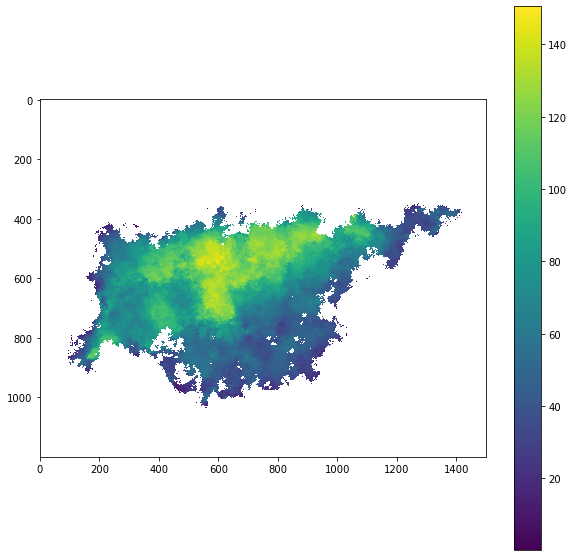

In [220]:
plt.figure(figsize=(10,10))
plt.imshow(diff_mean['MPS'][0],vmin=np.nanmin(diff_mean['MPS'][0]),vmax=np.nanmax(diff_mean['MPS'][0]))
plt.colorbar()
plt.show()

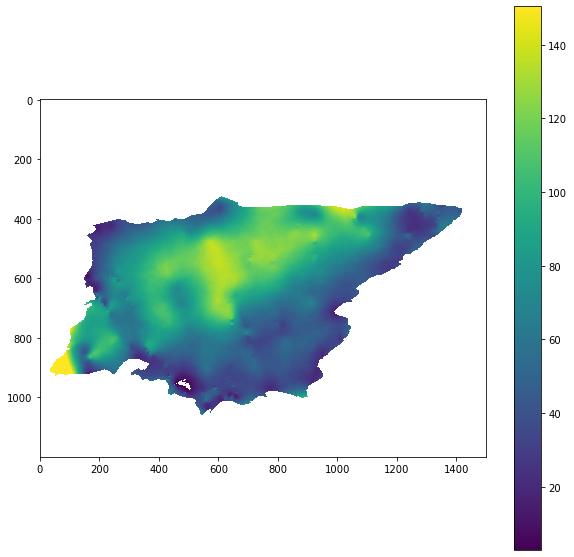

In [221]:
plt.figure(figsize=(10,10))
plt.imshow(diff_mean['GRF'][0],vmin=np.nanmin(diff_mean['GRF'][0]),vmax=np.nanmax(diff_mean['MPS'][0]))
plt.colorbar()
plt.show()